In [1]:
import pandas as pd
import numpy as np

In [2]:
tree_df = pd.read_csv("../data/tree_data.csv")
tree_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 40 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             7043 non-null   int64  
 1   age                                7043 non-null   int64  
 2   married                            7043 non-null   int64  
 3   number_of_dependents               7043 non-null   int64  
 4   zip_code                           7043 non-null   int64  
 5   population                         7043 non-null   int64  
 6   tenure_in_months                   7043 non-null   int64  
 7   phone_service                      7043 non-null   int64  
 8   avg_monthly_long_distance_charges  7043 non-null   float64
 9   multiple_lines                     7043 non-null   int64  
 10  internet_service                   7043 non-null   int64  
 11  avg_monthly_gb_download            7043 non-null   int64

## Train-Test Split

In [3]:
from sklearn.model_selection import train_test_split

# separate features and target
X = tree_df.drop(columns=["churn_label"])
y = tree_df['churn_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,
                                                    stratify=y)

# check class distributions
train_dist = y_train.value_counts(normalize=True).rename("Train Proportion")
test_dist = y_test.value_counts(normalize=True).rename("Test Proportion")
class_distribution = pd.concat([train_dist, test_dist], axis=1)

print(class_distribution)

             Train Proportion  Test Proportion
churn_label                                   
0                    0.734647         0.734564
1                    0.265353         0.265436


## Decision Tree Classifier

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# make predictions
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [5]:
# confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# ROC AUC score
auc = roc_auc_score(y_test, y_prob_dt)
print(f"ROC AUC Score: {auc:.2f}")

Confusion Matrix:
 [[998  37]
 [ 38 336]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96      1035
           1       0.90      0.90      0.90       374

    accuracy                           0.95      1409
   macro avg       0.93      0.93      0.93      1409
weighted avg       0.95      0.95      0.95      1409

ROC AUC Score: 0.93


**Insights:**
- **Accuracy:** 0.95
- **Recall for label 0:** 0.96 (few false negatives)
- **Recall for label 1:** 0.90 (few false negatives)
- **F-1 Score for label 1:** 0.90
- **ROC AUC Score:** 0.93 (model is able to separate the classes)

## RandomForest Classifier

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# make predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [7]:
# confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# ROC AUC score
auc = roc_auc_score(y_test, y_prob_rf)
print(f"ROC AUC Score: {auc:.2f}")

Confusion Matrix:
 [[1027    8]
 [  58  316]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97      1035
           1       0.98      0.84      0.91       374

    accuracy                           0.95      1409
   macro avg       0.96      0.92      0.94      1409
weighted avg       0.95      0.95      0.95      1409

ROC AUC Score: 0.98


**Insights:**
- **Accuracy:** 0.95
- **Precision for label 1:** 0.98 (few false positives)
- **Recall for label 1:** 0.84 (some churners missed)
- **F-1 Score for label 1:** 0.91
- **ROC AUC Score:** 0.98 (excellent ability to distinguish between classes)

## XGBoost Classifier

In [15]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# make predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

/Users/sowmyamaddali/Desktop/Sowmya/Git/customer-churn-prediction/venv/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [14:29:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [16]:
# confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

# ROC AUC score
auc = roc_auc_score(y_test, y_prob_xgb)
print(f"ROC AUC Score: {auc:.2f}")

Confusion Matrix:
 [[1018   17]
 [  39  335]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97      1035
           1       0.95      0.90      0.92       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409

ROC AUC Score: 0.99


**Insights:**
- **Accuracy:** 0.96
- **Precision for label 1:** 0.95 (RandomForest Classifier was slightly better!)
- **Recall for label 1:** 0.90 (very few churners missed)
- **F-1 Score for label 1:** 0.92
- **ROC AUC Score:** 0.99 (excellent ability to distinguish between classes)

## Comparing model results

In [17]:
# Classification report summary for each model
model_metrics = {
    "Logistic Regression": {
        "Accuracy": 0.93,
        "Precision (Churn)": 0.87,
        "Recall (Churn)": 0.87,
        "F1-score (Churn)": 0.87,
        "ROC AUC": 0.97
    },
    "Ridge Regression": {
        "Accuracy": 0.95,
        "Precision (Churn)": 0.92,
        "Recall (Churn)": 0.87,
        "F1-score (Churn)": 0.89,
        "ROC AUC": 0.97
    },
    "Lasso Regression": {
        "Accuracy": 0.94,
        "Precision (Churn)": 0.89,
        "Recall (Churn)": 0.86,
        "F1-score (Churn)": 0.88,
        "ROC AUC": 0.96
    },
    "Random Forest": {
        "Accuracy": 0.95,
        "Precision (Churn)": 0.98,
        "Recall (Churn)": 0.84,
        "F1-score (Churn)": 0.91,
        "ROC AUC": 0.98
    },
    "XGBoost": {
        "Accuracy": 0.96,
        "Precision (Churn)": 0.95,
        "Recall (Churn)": 0.90,
        "F1-score (Churn)": 0.92,
        "ROC AUC": 0.99
    }
}

# Convert to DataFrame
metrics_df = pd.DataFrame(model_metrics).T

In [19]:
display(metrics_df)

,Accuracy,Precision (Churn),Recall (Churn),F1-score (Churn),ROC AUC
Logistic Regression,0.93,0.87,0.87,0.87,0.97
Ridge Regression,0.95,0.92,0.87,0.89,0.97
Lasso Regression,0.94,0.89,0.86,0.88,0.96
Random Forest,0.95,0.98,0.84,0.91,0.98
XGBoost,0.96,0.95,0.90,0.92,0.99


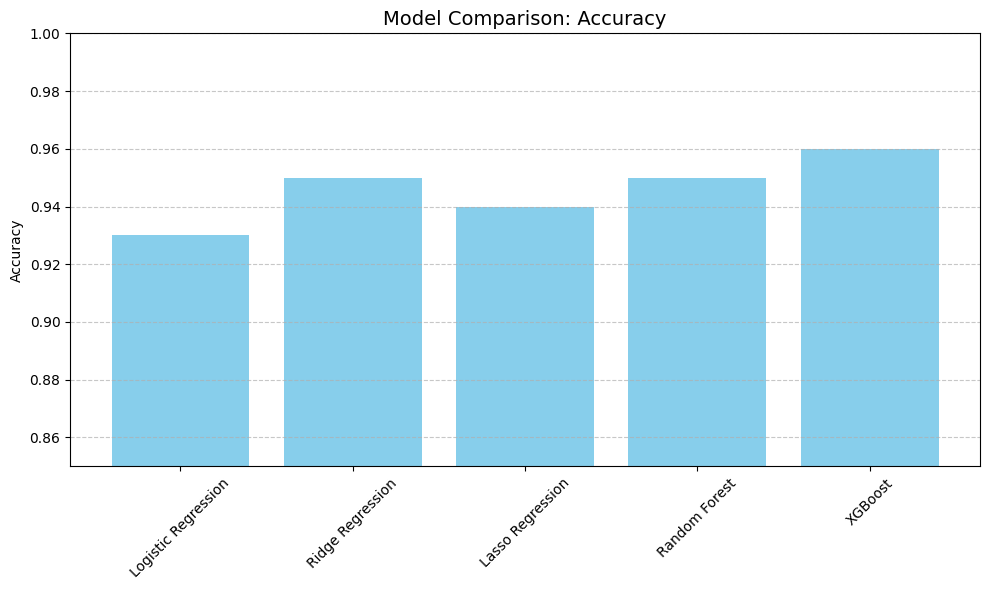

In [18]:
import matplotlib.pyplot as plt

# Plotting model accuracy
plt.figure(figsize=(10, 6))
plt.bar(metrics_df.index, metrics_df["Accuracy"], color="skyblue")
plt.title("Model Comparison: Accuracy", fontsize=14)
plt.ylabel("Accuracy")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()